In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [3]:
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')

In [4]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#### We can see that out of all Embarked,Age and Cabin have missing values, so we will tend them to first.
#### Embarked has only 2 missing values so we can fill them with the mean.

In [6]:
train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [7]:
train['Embarked'] = train['Embarked'].fillna('S')

In [8]:
train['Embarked'].isnull().sum()

np.int64(0)

In [9]:
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

In [10]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


#### We have fixed the empty values in the train file, we will need to do the same in the test file so the prediction doesnt lead to error.


In [11]:
test['Embarked'] =  test['Embarked'].fillna('S')
test['Embarked'].isnull().sum()

np.int64(0)

### Handling Missing `Age` Values

**Problem:** ~20% of `Age` values are missing. Filling all of them with one 
single number (e.g., the overall median) is too crude — it would assign 
the same age to a missing baby and a missing elderly passenger, which 
doesn't reflect reality.

**Better approach:** Extract each passenger's **Title** (Mr, Mrs, Miss, 
Master, etc.) from the `Name` column, then fill missing ages using the 
**median age within each title group** instead of one global median.

Why this works: titles carry an age signal.
- `Master` → historically used for young boys → low median age
- `Miss` → skews younger (unmarried women/girls) → moderate median age
- `Mrs` → adult women → higher median age
- `Mr` → adult men → higher median age

This way, a missing-age "Master" gets filled with a realistic *young* age, 
and a missing-age "Mr" gets filled with a realistic *adult* age — instead 
of forcing everyone to the same number.

**General principle:** When filling missing values, prefer the **median** 
over the **mean** if the data has outliers (median isn't skewed by extreme 
values). And when possible, fill *within meaningful groups* rather than 
using one global value — it preserves real patterns in the data instead 
of flattening them.

In [12]:
# we are gonna feature engineer a new column named title
# we will extract the title from the name column using regex syntax

train['Title'] = train['Name'].str.extract(r' ([A-Za-z]+)\.')

In [13]:
train['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [14]:
#Ms and Mme mean Miss in other languages so we'll club them
#Mme means Mrs. so we will club them
#Others are rare so we will put these into rare

train['Title'] = train['Title'].replace(['Mlle','Ms'],'Miss')
train['Title'] = train['Title'].replace('Mme','Miss')

rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Don','Dona', 'Lady', 'Sir', 'Capt', 'Countess', 'Jonkheer']
train['Title'] = train['Title'].replace(rare_titles,'Rare')

In [15]:
train['Title'].value_counts()

Title
Mr        517
Miss      186
Mrs       125
Master     40
Rare       23
Name: count, dtype: int64

In [16]:
train['Age'] = train.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

In [17]:
train['Age'].isnull().sum()

np.int64(0)

In [18]:
age_medians = train.groupby('Title')['Age'].median()
age_medians

Title
Master     3.5
Miss      21.5
Mr        30.0
Mrs       35.0
Rare      48.5
Name: Age, dtype: float64

In [19]:
# now filling the missing age values for our test dataset
test['Title'] = test['Name'].str.extract(r' ([A-Za-z]+)\.')
test['Title'] = test['Title'].replace(['Mlle', 'Ms'], 'Miss')
test['Title'] = test['Title'].replace('Mme', 'Mrs')
test['Title'] = test['Title'].replace(rare_titles, 'Rare')

test['Age'] = test['Age'].fillna(test['Title'].map(age_medians))

In [20]:
test['Age'].isnull().sum()

np.int64(0)

### Handling Missing `Age` Values (Summary)

**Steps taken:**
1. Extracted a `Title` (Mr, Mrs, Miss, Master, etc.) from the `Name` column
   using a regex pattern, since titles carry a strong age signal.
2. Cleaned up rare/foreign titles by grouping them:
   - `Mlle`, `Ms` → `Miss`
   - `Mme` → `Mrs`
   - All other rare titles (`Dr`, `Rev`, `Col`, `Major`, `Don`, `Lady`, 
     `Sir`, `Capt`, `Countess`, `Jonkheer`) → grouped into a single 
     `Rare` category, since each individually had too few samples to 
     compute a reliable median.
3. Computed the **median Age per Title, using `train` only**:

4. Used this single saved lookup table (`age_medians`) to fill missing 
   ages in **both** `train` and `test`:

   **Why compute medians from `train` only, and reuse them everywhere?**
- Avoids **data leakage** — `test` should be treated as unseen data; we 
  shouldn't use its own statistics to fill its own gaps.
- Avoids **fragile/unreliable statistics** — `test` has fewer rows (418 
  vs 891), so some title groups could have too few (or zero) known ages 
  to compute a trustworthy median on their own.
- Keeps a **single consistent source of truth**, rather than recalculating 
  the same kind of statistic in multiple places, which reduces the risk 
  of subtle bugs or inconsistent results.

**Result:** 0 missing values in `Age` for both `train` and `test`.

In [21]:
# Handling the missing Cabin values
# Most of it is missing so instead of discarding the whole columns we will convert it 
# yes/no if the record is known as the wealthier people are more like to have cabin
# recorded. We Feature Engineer a new column here

train['HasCabin'] = train['Cabin'].notnull().astype(int)

test['HasCabin'] = test['Cabin'].notnull().astype(int)

In [22]:
train[['Cabin', 'HasCabin']].head(10)

,Cabin,HasCabin
0,NaN,0
1,C85,1
2,NaN,0
3,C123,1
4,NaN,0
5,NaN,0
6,E46,1
7,NaN,0
8,NaN,0
9,NaN,0


## Data Cleaning Summary

- **Embarked**: 2 missing values filled with mode ('S').
- **Age**: ~20% missing. Extracted `Title` from `Name`, grouped rare 
  titles, computed median age per title from `train` only, and used it 
  to fill gaps in both `train` and `test` (avoids data leakage).
- **Cabin**: ~77% missing, too sparse to fill. Replaced with a new binary 
  feature `HasCabin` (1 = cabin recorded, 0 = not).

**Next up:** Feature engineering — encode categorical columns (`Sex`, 
`Embarked`, `Title`) into numbers, create `FamilySize` from `SibSp` + 
`Parch`, and drop unused columns (`Name`, `Ticket`, raw `Cabin`, 
`PassengerId`).

In [23]:
# making a new column for family size

train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

train[['SibSp','Parch','FamilySize','Survived']].head(10)

,SibSp,Parch,FamilySize,Survived
0,1,0,2,0
1,1,0,2,1
2,0,0,1,1
3,1,0,2,1
4,0,0,1,0
5,0,0,1,0
6,0,0,1,0
7,3,1,5,0
8,0,2,3,1
9,1,0,2,1


In [24]:
train['IsAlone'] = (train['FamilySize'] == 1).astype(int)
test['IsAlone'] = (test['FamilySize'] == 1).astype(int)

train[['FamilySize', 'IsAlone']].head(10)

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


In [25]:
train['Sex'] = train['Sex'].map({'male': 0, 'female' : 1})
test['Sex'] = test['Sex'].map({'male': 0, 'female' : 1})

train[['Name','Sex']].head(5)

,Name,Sex
0,"Braund, Mr. Owen Harris",0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1
2,"Heikkinen, Miss. Laina",1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1
4,"Allen, Mr. William Henry",0


In [26]:
train = pd.get_dummies(train, columns = ['Embarked','Title'], drop_first = True)
test = pd.get_dummies(test, columns = ['Embarked','Title'], drop_first = True)

In [27]:
train.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'HasCabin',
 'FamilySize',
 'IsAlone',
 'Embarked_Q',
 'Embarked_S',
 'Title_Miss',
 'Title_Mr',
 'Title_Mrs',
 'Title_Rare']

In [28]:
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch']

train = train.drop(columns=drop_cols)
test_ids = test['PassengerId']  # save this! we need it for the final submission file
test = test.drop(columns=drop_cols)

In [29]:
train.columns.tolist()

['Survived',
 'Pclass',
 'Sex',
 'Age',
 'Fare',
 'HasCabin',
 'FamilySize',
 'IsAlone',
 'Embarked_Q',
 'Embarked_S',
 'Title_Miss',
 'Title_Mr',
 'Title_Mrs',
 'Title_Rare']

In [30]:
test.columns.tolist()

['Pclass',
 'Sex',
 'Age',
 'Fare',
 'HasCabin',
 'FamilySize',
 'IsAlone',
 'Embarked_Q',
 'Embarked_S',
 'Title_Miss',
 'Title_Mr',
 'Title_Mrs',
 'Title_Rare']

In [31]:
#safety double check code block
missing_cols = set(train.columns) - set(test.columns) - {'Survived'}
extra_cols = set(test.columns) - set(train.columns)
print("In train but not test:", missing_cols)
print("In test but not train:", extra_cols)

In train but not test: set()
In test but not train: set()


## Feature Engineering Summary

- **FamilySize** = `SibSp + Parch + 1` — total family members aboard, 
  including the passenger themselves.
- **IsAlone** = 1 if `FamilySize == 1`, else 0 — isolates the "traveling 
  alone" signal, which showed a notably lower survival rate.
- **Encoding categorical columns** (models need numbers, not text):
  - `Sex`: simple 0/1 mapping (male=0, female=1) — safe for binary 
    categories since there's no fake ordering possible with only 2 values.
  - `Embarked`, `Title`: **one-hot encoded** (`pd.get_dummies`, 
    `drop_first=True`) since they have 3+ unordered categories — avoids 
    implying a fake numeric ranking between them.
- **Dropped unused columns**: `PassengerId`, `Name`, `Ticket`, `Cabin`, 
  `SibSp`, `Parch` — either replaced by better engineered features, or 
  not usable in raw form. `PassengerId` was saved separately as 
  `test_ids` before dropping, since it's needed for the final submission.

**Bug encountered & fixed:** `test.csv` contains a title ("Dona") that 
never appears in `train.csv`. Since our `rare_titles` list was built only 
from `train`, "Dona" wasn't folded into "Rare" for `test`, causing 
`train` and `test` to end up with mismatched one-hot encoded columns 
after `get_dummies`. Fixed by adding `'Dona'` to `rare_titles`, then 
restarting and re-running the full notebook.

**Lesson:** Always verify `train` and `test` have identical feature 
columns after encoding — categories present in one but not the other 
(rare labels, typos, edge cases) can silently break this.

**Result:** `train` and `test` now have identical, fully numeric feature 
columns, with `Survived` present only in `train`.

In [32]:
from sklearn.model_selection import train_test_split

X = train.drop(columns = ['Survived'])
y = train['Survived']

X_train,X_val,y_train,y_val = train_test_split(X,y,test_size = 0.2, random_state = 42)

### Splitting Data into Training and Validation Sets

**Why split?** We can't check how good our model is by testing it on 
`test.csv`, since we don't have the real answers for that set. Instead, 
we carve out a portion of `train.csv` (which *does* have answers) to use 
as a practice quiz.

```python
X = train.drop(columns=['Survived'])   # features (the "questions")
y = train['Survived']                  # target (the "answer key")

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
```

- **`X`** = all features, **`y`** = the `Survived` column only.
- **`test_size=0.2`** → 20% of rows set aside for validation, 80% for training.
- **`random_state=42`** → fixes the random shuffle so the split is 
  reproducible every time the cell runs.
- The function splits `X` and `y` **together, in sync** — a passenger's 
  features and their real survival answer always stay paired, whether 
  they land in the training group or the validation group.

**Output — 4 pieces:**
| Variable | Meaning |
|---|---|
| `X_train` | Features for the 80% training rows |
| `X_val` | Features for the 20% validation rows |
| `y_train` | Real answers for the training rows (used to teach the model) |
| `y_val` | Real answers for the validation rows (hidden from the model, used later to check its guesses) |

**One-line summary:** `X` = the features, `y` = the output. We split 
both into a "study set" (`_train`) and a "quiz set" (`_val`), keeping 
questions and answers correctly paired in both.

In [33]:
print(X_train.shape, X_val.shape)

(712, 13) (179, 13)


### What is Logistic Regression?

Despite the name having "regression" in it, Logistic Regression is used 
for **classification** (yes/no outcomes) here.

**Roughly how it works:** it looks at all your features, assigns each 
one a **weight** (how important/influential it is), combines them 
mathematically, and squashes the result into a **probability between 
0 and 1** — e.g., "73% chance this passenger survived." If that 
probability is above 0.5, it predicts "survived" (1); otherwise "died" (0).

We don't need to know the exact math to use it effectively — scikit-learn 
handles that for us.

**Why start with this model?** It's simple, fast, and interpretable — a 
good baseline to sanity-check that our data prep worked, before trying 
fancier models.

In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [35]:
#Evaluate on the Validation Set
#Remember X_val and y_val from the split — 
#the model has never seen these 179 passengers. Let's ask it to predict
#on them, then compare against the real answers.

from sklearn.metrics import accuracy_score

y_pred = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
print(accuracy)

0.8212290502793296


In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)
accuracy_rf = accuracy_score(y_val, y_pred_rf)
print(accuracy_rf)

0.8491620111731844


In [37]:
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X, y)

RandomForestClassifier(random_state=42)

In [38]:
test_predictions = final_model.predict(test)

print(test_predictions[:10])
print(len(test_predictions))

[0 0 0 1 1 0 0 0 1 0]
418


## Model Training & Evaluation

Before predicting on the real `test.csv`, we split `train.csv` into an 
80% training set and a 20% validation set (`train_test_split`, 
`random_state=42`). This lets us measure accuracy on data the model has 
never seen, without using up real Kaggle submissions.

### Baseline: Logistic Regression
A simple, interpretable model — assigns weights to each feature and 
outputs a probability of survival.
- **Validation accuracy: 82.1%**

### Stronger model: Random Forest
An ensemble of 100 decision trees (`n_estimators=100`), each trained on 
a randomized subset of data/features, voting together on a final 
prediction. Ensembles like this typically smooth out the overfitting 
that a single decision tree is prone to.
- **Validation accuracy: 84.9%**

### Comparison

| Model | Validation Accuracy |
|---|---|
| Logistic Regression | 82.1% |
| **Random Forest** | **84.9%** ✅ |

For reference, always predicting "died" (the majority class, ~62% of 
passengers) would score ~61-62% — so both models clearly learned real 
patterns well beyond blind guessing.

**Decision:** Random Forest outperformed Logistic Regression on unseen 
validation data, so it was chosen as the final model.

### Final Model
Once Random Forest was selected, it was **retrained on the full 
`train.csv`** (all 891 rows, not just the 80% training split) to make 
use of every available data point before generating real predictions 
on `test.csv`.


In [39]:
submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': test_predictions
})

submission.to_csv('submission.csv', index=False)

In [40]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,1


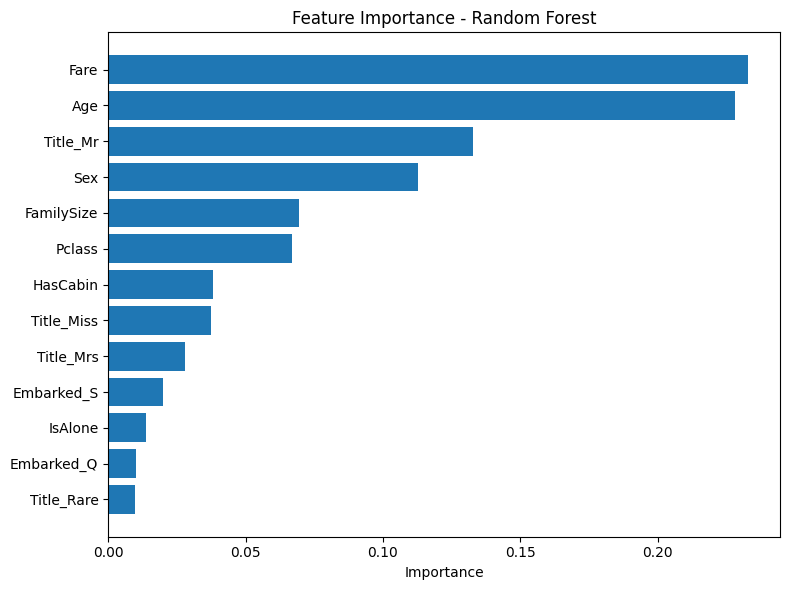

In [41]:
import matplotlib.pyplot as plt

importances = final_model.feature_importances_
feature_names = X.columns

feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(feat_importance_df['Feature'], feat_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

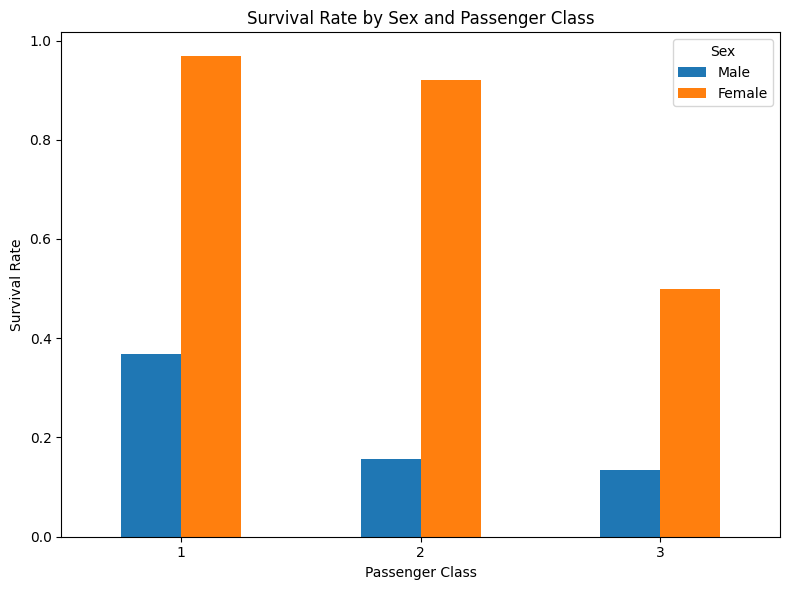

In [42]:
survival_by_sex_class = train.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()

survival_by_sex_class.plot(kind='bar', figsize=(8, 6))
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class')
plt.title('Survival Rate by Sex and Passenger Class')
plt.xticks(rotation=0)
plt.legend(['Male', 'Female'], title='Sex')
plt.tight_layout()
plt.savefig('survival_by_sex_class.png')
plt.show()

In [43]:
from sklearn.metrics import classification_report

print("Logistic Regression:")
print(classification_report(y_val, y_pred))

print("Random Forest:")
print(classification_report(y_val, y_pred_rf))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       105
           1       0.78      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179

Random Forest:
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       105
           1       0.82      0.81      0.82        74

    accuracy                           0.85       179
   macro avg       0.84      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179

